## Airlines Classification Model

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import re

### load dataset

In [2]:
flights_final = pd.read_csv('airline_dataset_normalized/flights_final_for_model.csv')
print(flights_final.shape)
flights_final.head()

(447717, 698)


,SCHEDULED_TIME,DISTANCE,ARRIVAL_PROP,DEPARTURE_PROP,AIRLINE_ARRIVAL_PROP,AIRLINE_DEPARTURE_PROP,ARRIVAL_FLIGHT_COUNT,DEPARTURE_FLIGHT_COUNT,TOTAL_FLIGHTS_ARRIVAL_HOUR,TOTAL_FLIGHTS_DEPARTURE_HOUR,...,ARRIVE_TYS,ARRIVE_UST,ARRIVE_VEL,ARRIVE_VLD,ARRIVE_VPS,ARRIVE_WRG,ARRIVE_XNA,ARRIVE_YAK,ARRIVE_YUM,LATE_ARRIVAL
0,205.0,1448.0,0.854167,0.186704,0.121951,0.090909,41,132,48,707,...,0,0,0,0,0,0,0,0,0,0
1,280.0,2330.0,0.261402,0.185075,0.080851,0.209677,235,62,899,335,...,0,0,0,0,0,0,0,0,0,0
2,286.0,2296.0,0.356370,0.185075,0.084112,0.112903,428,62,1201,335,...,0,0,0,0,0,0,0,0,0,0
3,285.0,2342.0,0.261402,0.185075,0.080851,0.209677,235,62,899,335,...,0,0,0,0,0,0,0,0,0,0
4,235.0,1448.0,0.777778,0.185075,0.142857,0.080645,21,62,27,335,...,0,0,0,0,0,0,0,0,0,0


In [3]:
## targets
target_features = ['LATE_ARRIVAL']

In [4]:
### continuous features
model_features = ['SCHEDULED_TIME','DISTANCE',
                  'ARRIVAL_PROP','DEPARTURE_PROP',
                  'AIRLINE_ARRIVAL_PROP','AIRLINE_DEPARTURE_PROP',
                  'ARRIVAL_FLIGHT_COUNT','DEPARTURE_FLIGHT_COUNT',
                  'TOTAL_FLIGHTS_ARRIVAL_HOUR', 'TOTAL_FLIGHTS_DEPARTURE_HOUR']

In [5]:
## dimension features 
bool_prefixes = ('DEPART_', 'DEPARTURE_', 'ARRIVAL_', 'ARRIVE_', 'is_', 'AIRLINE_')
dim_features = [c for c in flights_final.columns if c.startswith(bool_prefixes) 
                and c not in['ARRIVAL_TIME','ARRIVAL_DELAY',
                             'ARRIVAL_HOUR','DEPARTURE_HOUR',
                             'DEPARTURE_TIME','DEPARTURE_DELAY','AIRLINE_NAME']]
dim_features = [c for c in dim_features if c not in model_features and c not in target_features]

### correlation features

In [6]:
# Focused heatmap — top correlated pairs (|corr| > 0.5, excluding self)
corr_ = flights_final[[c for c in dim_features if c.startswith('AIRLINE')] + ['LATE_ARRIVAL']].corr().abs()
pairs = (corr_.where(np.triu(np.ones(corr_.shape), k=1).astype(bool))
             .stack()
             .sort_values(ascending=False))

print('Top correlated pairs (|r| > 0.5):')
print(pairs[pairs > 0.5].round(3))

Top correlated pairs (|r| > 0.5):
Series([], dtype: float64)


In [7]:
# Focused heatmap — top correlated pairs (|corr| > 0.5, excluding self)
corr_ = flights_final[[c for c in dim_features if c.startswith('ARRIVE')] + ['LATE_ARRIVAL']].corr().abs()
pairs = (corr_.where(np.triu(np.ones(corr_.shape), k=1).astype(bool))
             .stack()
             .sort_values(ascending=False))

print('Top correlated pairs (|r| > 0.5):')
print(pairs[pairs > 0.5].round(3))

Top correlated pairs (|r| > 0.5):
Series([], dtype: float64)


In [8]:
# Focused heatmap — top correlated pairs (|corr| > 0.5, excluding self)
corr_ = flights_final[[c for c in model_features] + ['LATE_ARRIVAL']].corr().abs()
pairs = (corr_.where(np.triu(np.ones(corr_.shape), k=1).astype(bool))
             .stack()
             .sort_values(ascending=False))

print('Top correlated pairs (|r| > 0.5):')
print(pairs[pairs > 0.5].round(3))

Top correlated pairs (|r| > 0.5):
SCHEDULED_TIME          DISTANCE                        0.978
AIRLINE_ARRIVAL_PROP    AIRLINE_DEPARTURE_PROP          0.911
ARRIVAL_FLIGHT_COUNT    TOTAL_FLIGHTS_ARRIVAL_HOUR      0.838
DEPARTURE_FLIGHT_COUNT  TOTAL_FLIGHTS_DEPARTURE_HOUR    0.748
ARRIVAL_FLIGHT_COUNT    DEPARTURE_FLIGHT_COUNT          0.721
DEPARTURE_FLIGHT_COUNT  TOTAL_FLIGHTS_ARRIVAL_HOUR      0.720
ARRIVAL_FLIGHT_COUNT    TOTAL_FLIGHTS_DEPARTURE_HOUR    0.720
ARRIVAL_PROP            DEPARTURE_PROP                  0.529
                        TOTAL_FLIGHTS_ARRIVAL_HOUR      0.521
dtype: float64


<Axes: >

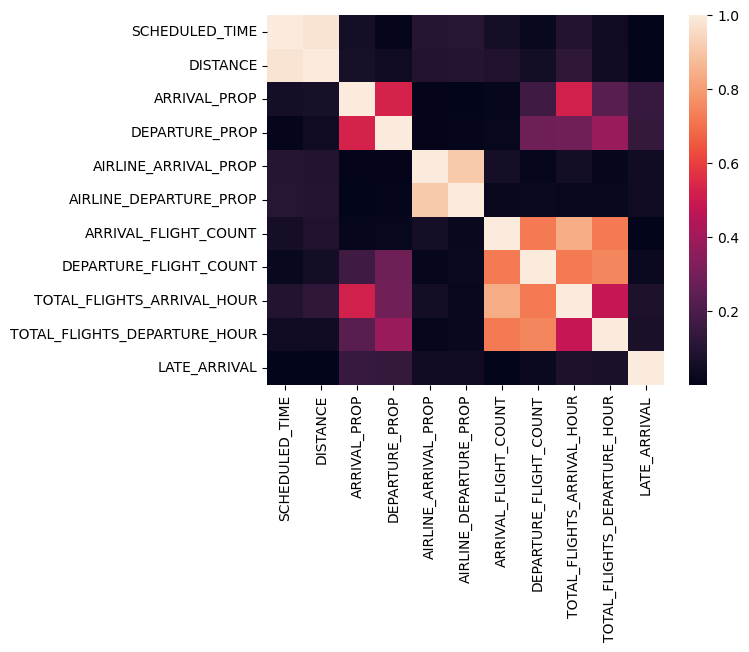

In [9]:
sns.heatmap(corr_)

### split training and test

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    flights_final.drop(['LATE_ARRIVAL'], axis=1), 
    flights_final['LATE_ARRIVAL'], 
    test_size=0.3, random_state=42,
)


In [12]:
## split test in half for validation set
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [13]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(313401, 697)
(67158, 697)
(67158, 697)


### normalize features

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
model_features

['SCHEDULED_TIME',
 'DISTANCE',
 'ARRIVAL_PROP',
 'DEPARTURE_PROP',
 'AIRLINE_ARRIVAL_PROP',
 'AIRLINE_DEPARTURE_PROP',
 'ARRIVAL_FLIGHT_COUNT',
 'DEPARTURE_FLIGHT_COUNT',
 'TOTAL_FLIGHTS_ARRIVAL_HOUR',
 'TOTAL_FLIGHTS_DEPARTURE_HOUR']

In [16]:
scaler_ = StandardScaler()

model_features_scaled = [m+'_SCALED' for m in model_features]
X_train[model_features_scaled] = scaler_.fit_transform(X_train[model_features])


## apply scaler to test and validation
X_test[model_features_scaled] = scaler_.transform(X_test[model_features])
X_val[model_features_scaled] = scaler_.transform(X_val[model_features])

/var/folders/d0/q4rwdhyx3bg4m8jmrnyj715r0000gn/T/ipykernel_67798/3990957704.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[model_features_scaled] = scaler_.fit_transform(X_train[model_features])
/var/folders/d0/q4rwdhyx3bg4m8jmrnyj715r0000gn/T/ipykernel_67798/3990957704.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test[model_features_scaled] = scaler_.transform(X_test[model_features])
/var/folders/d0/q4rwdhyx3bg4m8jmrnyj715r0000gn/T/ipykernel_67798/3990957704.py:9: PerformanceWarning: DataFrame is highly fr

In [17]:
X_train.drop(model_features, axis=1, inplace=True)
X_test.drop(model_features, axis=1, inplace=True)
X_val.drop(model_features, axis=1, inplace=True)

In [18]:
X_train.head(3)

,DEPART_10PM,DEPART_11AM,DEPART_11PM,DEPART_12AM,DEPART_12PM,DEPART_1AM,DEPART_1PM,DEPART_2AM,DEPART_2PM,DEPART_3AM,...,SCHEDULED_TIME_SCALED,DISTANCE_SCALED,ARRIVAL_PROP_SCALED,DEPARTURE_PROP_SCALED,AIRLINE_ARRIVAL_PROP_SCALED,AIRLINE_DEPARTURE_PROP_SCALED,ARRIVAL_FLIGHT_COUNT_SCALED,DEPARTURE_FLIGHT_COUNT_SCALED,TOTAL_FLIGHTS_ARRIVAL_HOUR_SCALED,TOTAL_FLIGHTS_DEPARTURE_HOUR_SCALED
216768,0,0,0,0,0,0,0,0,0,0,...,0.595085,0.369395,0.051017,0.075632,-0.260141,-0.031862,1.084646,1.249890,0.848372,1.019624
153655,0,0,0,0,0,0,0,0,1,0,...,1.600326,1.780912,0.907107,-0.218342,-0.596220,-0.651319,0.169859,0.220948,-0.621018,0.370665
156753,0,0,0,0,0,0,0,0,0,0,...,0.350567,0.024584,-0.156151,0.040688,-1.010773,-0.958602,0.459542,0.935343,0.469741,0.763312


### PCA

In [19]:
from sklearn.decomposition import PCA

In [20]:
pca = PCA(n_components=.95).fit(X_train)

pca_features = pca.transform(X_train)
X_train_pca = pd.DataFrame(pca_features)

pca_val_features = pca.transform(X_val)
X_val_pca = pd.DataFrame(pca_val_features)

pca_test_features = pca.transform(X_test)
X_test_pca = pd.DataFrame(pca_test_features)

In [21]:
print(X_train_pca.shape)
X_train_pca.head(3)

(313401, 105)


,0,1,2,3,4,5,6,7,8,9,...,95,96,97,98,99,100,101,102,103,104
0,1.982829,-0.829027,-0.436996,0.514411,0.288934,-0.091441,-0.150822,0.812926,-0.021418,0.113292,...,0.065973,0.020295,-0.019415,0.053192,0.026393,-0.014633,0.046844,0.002874,-0.030684,0.064865
1,-0.460418,-2.432363,-0.941105,0.987347,0.529356,0.048208,-0.211702,-0.203001,-0.017870,-0.346708,...,-0.034523,-0.073303,-0.013666,-0.158621,-0.022545,-0.009406,-0.079324,-0.041209,-0.035167,-0.108051
2,1.326200,-1.366045,0.204490,-0.519747,0.188157,-0.440699,-0.135800,-0.244645,-0.064662,-0.254939,...,-0.002643,0.006096,-0.001166,0.007393,0.006928,0.005595,0.040584,0.009027,0.032616,0.005131


In [22]:
print(X_val_pca.shape)
X_val_pca.head(3)

(67158, 105)


,0,1,2,3,4,5,6,7,8,9,...,95,96,97,98,99,100,101,102,103,104
0,1.260634,-0.118761,0.658262,-0.471705,0.192850,-0.332432,-0.101566,-0.064742,0.007446,0.042318,...,-0.038508,-0.007867,-0.014374,0.156799,-0.056500,-0.018787,-0.006555,0.000809,-0.039040,-0.205826
1,1.055035,-0.381630,-0.324103,0.467282,-0.450327,0.544030,-0.024074,-0.217859,-0.028632,-0.286842,...,0.014826,-0.011548,-0.008249,-0.020988,0.045797,-0.009856,0.014889,0.008814,-0.042634,-0.022651
2,-0.908948,0.327686,-0.170880,-0.355993,0.096294,-0.077556,1.007618,-0.189277,-0.239368,0.946906,...,0.012562,0.118087,-0.057346,-0.083239,-0.151436,0.011300,-0.187837,0.365662,0.005067,0.186037


### classification model

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, roc_auc_score, classification_report
from sklearn.svm import SVC
import matplotlib.pyplot as plt

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Decision Tree

In [25]:
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train_pca, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [26]:
# Extract the structural weights (loadings)
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca.n_components_)], 
    index=X_train.columns
)


## Feature importances within the PCA features
important_features_pc1 = loadings['PC1'].abs().sort_values(ascending=False)
print("Top 5 original features contributing to PC1:")
print(important_features_pc1.head(15))

Top 5 original features contributing to PC1:
TOTAL_FLIGHTS_ARRIVAL_HOUR_SCALED      0.505169
ARRIVAL_FLIGHT_COUNT_SCALED            0.500889
DEPARTURE_FLIGHT_COUNT_SCALED          0.497981
TOTAL_FLIGHTS_DEPARTURE_HOUR_SCALED    0.419289
ARRIVAL_PROP_SCALED                    0.147090
DISTANCE_SCALED                        0.115491
SCHEDULED_TIME_SCALED                  0.099165
DEPARTURE_PROP_SCALED                  0.087216
is_Saturday                            0.048986
ARRIVE_11PM                            0.037491
DEPART_9PM                             0.033725
AIRLINE_ARRIVAL_PROP_SCALED            0.031619
ARRIVE_10PM                            0.029754
DEPART_10PM                            0.027270
DEPART_5AM                             0.026671
Name: PC1, dtype: float64


In [27]:
dt_results = dt_clf.predict(X_val_pca)

In [28]:
print(classification_report(y_val, dt_results, labels=dt_clf.classes_))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85     53355
           1       0.43      0.43      0.43     13803

    accuracy                           0.76     67158
   macro avg       0.64      0.64      0.64     67158
weighted avg       0.77      0.76      0.77     67158



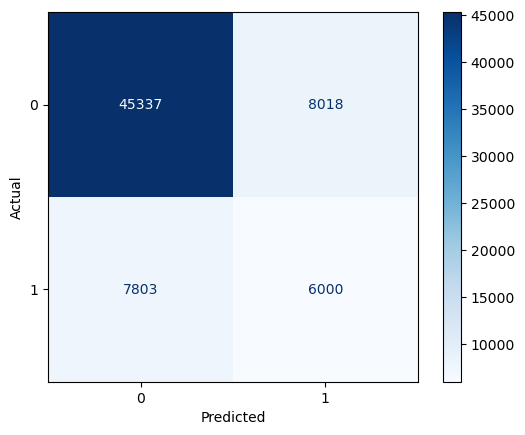

In [29]:
cm = confusion_matrix(y_val, dt_results, labels=dt_clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Random Forest

In [30]:
rf_clf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_clf.fit(X_train_pca, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [31]:
rf_results = rf_clf.predict(X_val_pca)

In [32]:
print(classification_report(y_val, rf_results, labels=rf_clf.classes_))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89     53355
           1       0.58      0.51      0.54     13803

    accuracy                           0.82     67158
   macro avg       0.73      0.71      0.72     67158
weighted avg       0.82      0.82      0.82     67158



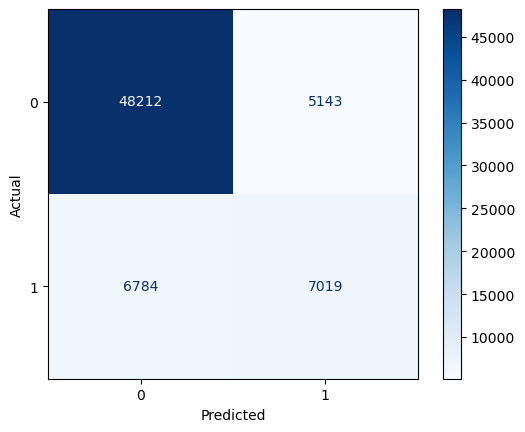

In [33]:
cm = confusion_matrix(y_val, rf_results, labels=rf_clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Logistic Regression

In [34]:
log_clf = LogisticRegression(random_state=42, class_weight='balanced').fit(X_train_pca, y_train)

In [35]:
log_results = log_clf.predict(X_val_pca)

In [36]:
print(classification_report(y_val, log_results, labels=log_clf.classes_))

              precision    recall  f1-score   support

           0       0.87      0.61      0.71     53355
           1       0.30      0.64      0.40     13803

    accuracy                           0.61     67158
   macro avg       0.58      0.62      0.56     67158
weighted avg       0.75      0.61      0.65     67158



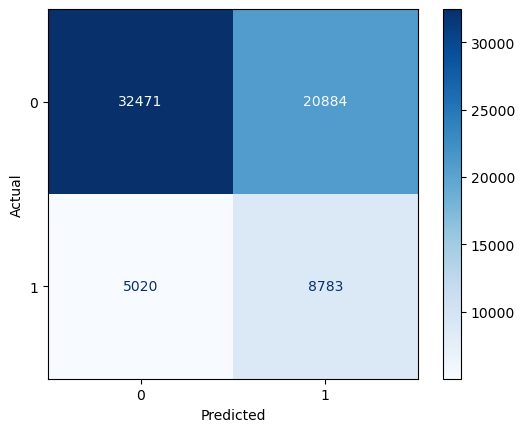

In [37]:
cm = confusion_matrix(y_val, log_results, labels=log_clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Training Summary Stats
Random Forest had highest accuracy training and f1-score (82%)

In [38]:
model_results = {
    "Logistic Regression": log_results,
    "Decision Tree": dt_results,
    "Random Forest": rf_results
}

In [39]:
# Loop through and print the report for each model
for model_name, predictions in model_results.items():
    print(f"=== {model_name} Classification Report ===")
    print(classification_report(y_val, predictions, labels=log_clf.classes_))
    print("\n" + "="*50 + "\n")

=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.61      0.71     53355
           1       0.30      0.64      0.40     13803

    accuracy                           0.61     67158
   macro avg       0.58      0.62      0.56     67158
weighted avg       0.75      0.61      0.65     67158



=== Decision Tree Classification Report ===
              precision    recall  f1-score   support

           0       0.85      0.85      0.85     53355
           1       0.43      0.43      0.43     13803

    accuracy                           0.76     67158
   macro avg       0.64      0.64      0.64     67158
weighted avg       0.77      0.76      0.77     67158



=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     53355
           1       0.58      0.51      0.54     13803

    accuracy                           0

In [40]:
training_summary = pd.DataFrame()

for model_name, predictions in model_results.items():
    report = classification_report(y_val, predictions, labels=log_clf.classes_, output_dict=True)
    
    training_summary = pd.concat([training_summary,
                                   pd.DataFrame([report["weighted avg"]]).join(
                                       pd.DataFrame([report['accuracy']], columns=['accuracy'])).join(
                                       pd.DataFrame([model_name], columns=['model']))])
    
    
training_summary.sort_values(['f1-score'], ascending=False, inplace=True)
training_summary.reset_index(drop=True, inplace=True)


In [41]:
training_summary

,precision,recall,f1-score,support,accuracy,model
0,0.815085,0.822404,0.818137,67158.0,0.822404,Random Forest
1,0.765782,0.764421,0.765094,67158.0,0.764421,Decision Tree
2,0.748939,0.614283,0.650987,67158.0,0.614283,Logistic Regression


### Final Model Evaluation on test set
All models drop in metric evaluations; but Random Forest stays slightly ahead of Decision Tree

In [42]:
rf_test = rf_clf.predict(X_test_pca)
dt_test = dt_clf.predict(X_test_pca)
log_test = log_clf.predict(X_test_pca)

In [43]:
final_model_results = {
    "Logistic Regression": log_test,
    "Decision Tree": dt_test,
    "Random Forest": rf_test
}

In [44]:
test_summary = pd.DataFrame()

for model_name, predictions in final_model_results.items():
    report = classification_report(y_val, predictions, labels=log_clf.classes_, output_dict=True)
    
    test_summary = pd.concat([test_summary,
                                   pd.DataFrame([report["weighted avg"]]).join(
                                       pd.DataFrame([report['accuracy']], columns=['accuracy'])).join(
                                       pd.DataFrame([model_name], columns=['model']))])
    
    
test_summary.sort_values(['f1-score'], ascending=False, inplace=True)
test_summary.reset_index(drop=True, inplace=True)


In [45]:
test_summary

,precision,recall,f1-score,support,accuracy,model
0,0.673075,0.689687,0.680974,67158.0,0.689687,Random Forest
1,0.672480,0.673606,0.673041,67158.0,0.673606,Decision Tree
2,0.675836,0.535707,0.579937,67158.0,0.535707,Logistic Regression


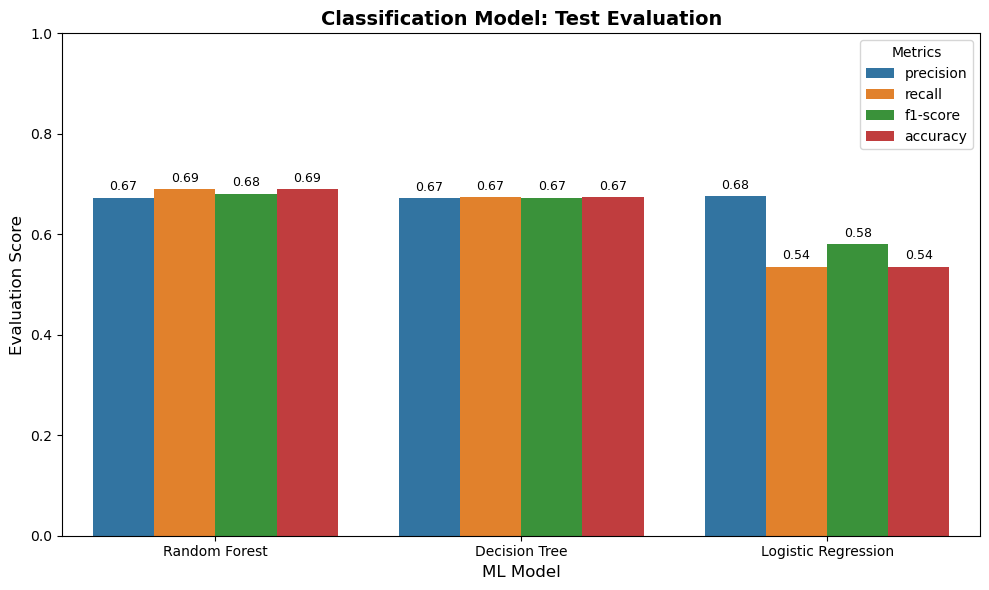

In [58]:
df_melted = test_summary.melt(
    id_vars="model",
    value_vars=["precision", "recall", "f1-score", "accuracy"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_melted, x="model", y="Score", hue="Metric",
)

plt.title("Classification Model: Test Evaluation", fontsize=14, fontweight="bold")
plt.xlabel("ML Model", fontsize=12)
plt.ylabel("Evaluation Score", fontsize=12)
plt.ylim(0, 1.0)
plt.legend(title="Metrics")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()


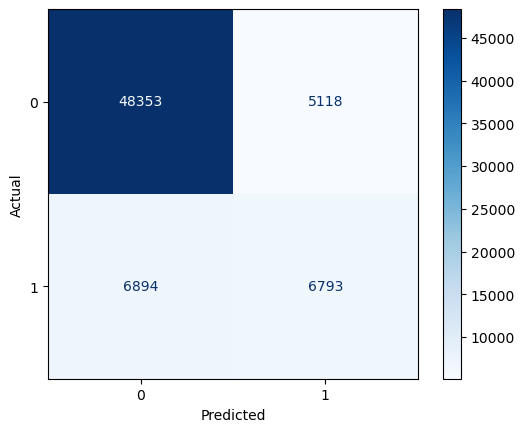

In [59]:
## confusion matrix of True Positive, True Negative, False Positive, False Negative
cm = confusion_matrix(y_test, rf_test, labels=log_clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()